# MPC

This script runs an optimal MPC (using casadi) for the 1/4 drone case study, using a NARX model identified.

In [1]:
# 1. Imports and Definitions
import numpy as np
import matplotlib.pyplot as plt
import time
import re
from tqdm.auto import tqdm
from casadi import SX, MX, DM, Function, nlpsol, vertcat
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# sysid library (used to load the measured 1/4 drone datasets)
try:
    from sysid import readData
except ImportError:
    !pip install -q git+https://github.com/helonayala/sysid.git
    from sysid import readData

Ts = 0.05  # Sampling time in seconds
ny_model = 5
nu_model = 5
nx = ny_model + nu_model


In [2]:
# 2. CasADi state-space NARX model (identified in narmax_example_drone, hard-coded)
# Selected terms and parameters (FROLS; trained on multisine + steps, ny=nu=5, l=2).
NARX_TERMS = ['y(k-1)', 'y(k-2)', 'u(k-2)u(k-3)', 'y(k-1)u(k-5)', 'y(k-3)',
              'u(k-4)u(k-5)', 'y(k-1)y(k-1)', 'y(k-4)', 'y(k-1)u(k-4)', 'u(k-1)u(k-5)']
NARX_THETA = [1.4939474973237645, -0.334494804495296, 0.0006088105544764172,
              0.00022896939867797587, -0.029051085139499146, 0.0006221374338774531,
              0.00019840982503746104, -0.17086373049395692, -0.0002697816501566133,
              -0.00016421277937507197]

x = SX.sym('x', nx)
y_syms = [x[i] for i in range(ny_model)]              # y(k-1) ... y(k-ny)
u_syms = [x[ny_model + i] for i in range(nu_model)]   # u(k-1) ... u(k-nu)
u_sym = SX.sym('u')

def _factor(tok):
    v, lag = re.match(r'([yu])\(k-(\d+)\)', tok).groups()
    return (y_syms if v == 'y' else u_syms)[int(lag) - 1]

def _term_expr(name):
    if name == 'constant':
        return SX(1.0)
    e = SX(1.0)
    for tok in re.findall(r'[yu]\(k-\d+\)', name):
        e = e * _factor(tok)
    return e

# y(k) = sum_i theta_i * term_i
y_k = SX(0)
for _name, _th in zip(NARX_TERMS, NARX_THETA):
    y_k = y_k + _th * _term_expr(_name)

y_next = vertcat(y_k, x[0:ny_model - 1])
u_next = vertcat(u_sym, x[ny_model:ny_model + nu_model - 1])
x_next = vertcat(y_next, u_next)

F = Function('F', [x, u_sym], [x_next, y_k], ['x0', 'p'], ['xf', 'yk'])


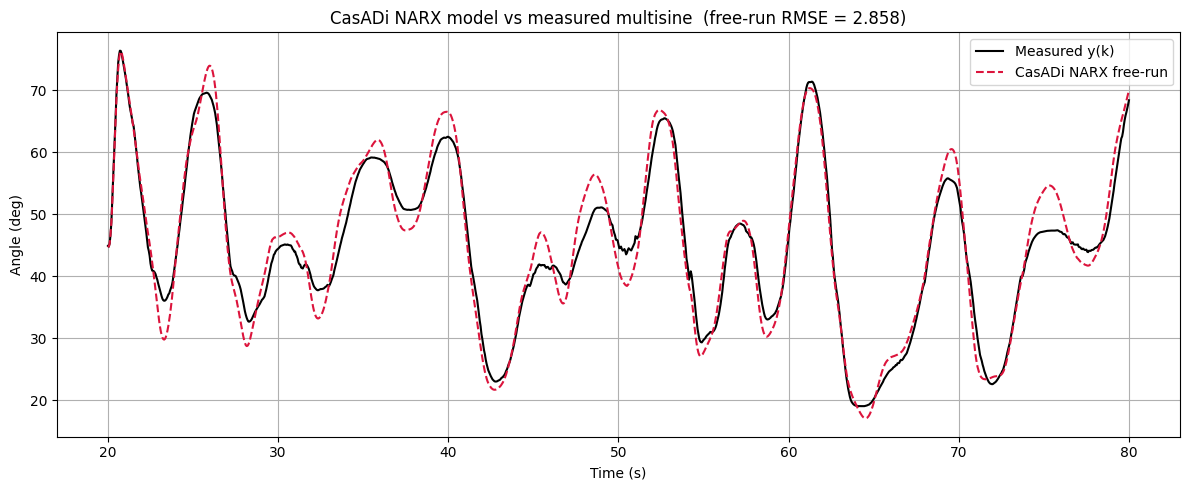

In [3]:
# 2b. Open-loop validation: free-run the CasADi state-space over the measured
#     multisine data (same selection used for identification) and compare.
T_START, T_END, DECIMATION = 20.0, 80.0, 5

def load_processed(name, t0=T_START, t1=T_END, dec=DECIMATION):
    """Load a 1/4 drone dataset, keep t in [t0, t1] s and decimate. Returns u, y, t, ref."""
    y, u, t, ref = readData('quarter_drone', name, return_ref=True)
    idx = np.where((t >= t0) & (t <= t1))[0]
    sl = slice(idx[0], idx[-1] + 1, dec)
    return u[sl], y[sl], t[sl], ref[sl]

u_ms, y_ms, t_ms, ref_ms = load_processed('multiseno')
ml = max(ny_model, nu_model)

# initial state from measured history: [y(k-1..k-ny), u(k-1..k-nu)] at k=ml
x_state = np.concatenate([y_ms[ml-1::-1][:ny_model], u_ms[ml-1::-1][:nu_model]])
y_casadi = np.zeros(len(y_ms)); y_casadi[:ml] = y_ms[:ml]
for k in range(ml, len(y_ms)):
    res = F(x0=x_state, p=u_ms[k])
    x_state = np.array(res['xf']).flatten()
    y_casadi[k] = float(res['yk'])

rmse = np.sqrt(np.mean((y_ms[ml:] - y_casadi[ml:]) ** 2))
plt.figure(figsize=(12, 5))
plt.plot(t_ms, y_ms, 'k', label='Measured y(k)')
plt.plot(t_ms, y_casadi, '--', color='crimson', label='CasADi NARX free-run')
plt.xlabel('Time (s)'); plt.ylabel('Angle (deg)')
plt.title(f'CasADi NARX model vs measured multisine  (free-run RMSE = {rmse:.3f})')
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()


In [4]:
# 3. MPC Setup
N = 10
data = {
    'Ts': Ts,
    'x0': np.zeros(nx),
    'u_min': np.array([0.0]),
    'u_max': np.array([100.0]),
    'u_guess': np.array([0.0]),
    'x_guess': np.zeros(nx),
    'tol': 1e-8,
}

def vcat(lst):
    return vertcat(*[DM(x) if not hasattr(x, 'is_symbolic') else x for x in lst])

w, lbw, ubw, w0 = [], [], [], []
g, lbg, ubg = [], [], []
J = 0

xk_param = MX.sym('xk_param', nx)
Pref = MX.sym('Pref', N)

xk = MX.sym('x0', nx)
w.append(xk)
lbw.append(np.full(nx, -np.inf))
ubw.append(np.full(nx, np.inf))
w0.append(data['x_guess'])

g.append(xk - xk_param)
lbg.append(np.zeros(nx))
ubg.append(np.zeros(nx))

for k in range(N):
    uk = MX.sym(f'u_{k}', 1)
    w.append(uk)
    lbw.append(data['u_min'])
    ubw.append(data['u_max'])
    w0.append(data['u_guess'])
    
    Fk = F(x0=xk, p=uk)
    xnext = Fk['xf']
    yk = Fk['yk']
    
    if k == 0:
        du = uk - xk[ny_model]
    else:
        du = uk - u_prev
    u_prev = uk
    
    J = J + 1e3 * (yk - Pref[k])**2 + 0.1 * uk**2 + 50.0 * du**2
    
    xk = MX.sym(f'x_{k+1}', nx)
    w.append(xk)
    lbw.append(np.full(nx, -np.inf))
    ubw.append(np.full(nx, np.inf))
    w0.append(data['x_guess'])
    
    g.append(xk - xnext)
    lbg.append(np.zeros(nx))
    ubg.append(np.zeros(nx))

w = vertcat(*w)
lbw = vcat(lbw)
ubw = vcat(ubw)
w0 = vcat(w0)
g = vertcat(*g)
lbg = vcat(lbg)
ubg = vcat(ubg)

nlp = {'x': w, 'g': g, 'f': J, 'p': vertcat(xk_param, Pref)}
solver = nlpsol('solver', 'ipopt', nlp, {'ipopt.print_level': 0, 'print_time': 0})


In [5]:
# 4. Reference Sequence Generation
# Sequence of 5s each, from 0 to 90 with step of 10
step_duration = 5.0
samples_per_step = int(round(step_duration / Ts))
step_levels = np.arange(0, 100, 10)  # 0, 10, ..., 90

t_total = len(step_levels) * step_duration
steps = len(step_levels) * samples_per_step

tvec = np.arange(0, t_total, Ts)
x2ref = np.zeros(steps)

for i, level in enumerate(step_levels):
    x2ref[i*samples_per_step : (i+1)*samples_per_step] = level

# Padding for MPC horizon
x2ref_full = np.concatenate([x2ref, np.full(N, 90.0)])


In [6]:
# 5. Simulation Loop
xsim = np.zeros((nx, 1))
ysim = []
usim = []
tvec_sim = []
dtvec = []

w0_val = np.zeros(w.shape[0])

for k in tqdm(range(steps), desc="MPC Simulation"):
    t = k * Ts
    ref_window = x2ref_full[k : k + N]
    
    pval = np.concatenate([xsim[:, -1], ref_window])
    
    tic = time.perf_counter()
    sol = solver(x0=w0_val, lbx=lbw, ubx=ubw, lbg=lbg, ubg=ubg, p=pval)
    dtvec.append(time.perf_counter() - tic)
    
    w_opt = sol['x'].full().flatten()
    u_opt = w_opt[nx] # The first u after the initial x0
    
    # Open Loop Simulation using NARX model F
    sim_step = F(x0=xsim[:, -1], p=u_opt)
    xk1 = sim_step['xf'].full().flatten()
    yk = sim_step['yk'].full().item()
    
    xsim = np.c_[xsim, xk1]
    usim.append(u_opt)
    ysim.append(yk)
    tvec_sim.append(t)
    
    # Warm start
    w0_val = w_opt


MPC Simulation:   0%|          | 0/1000 [00:00<?, ?it/s]


******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************



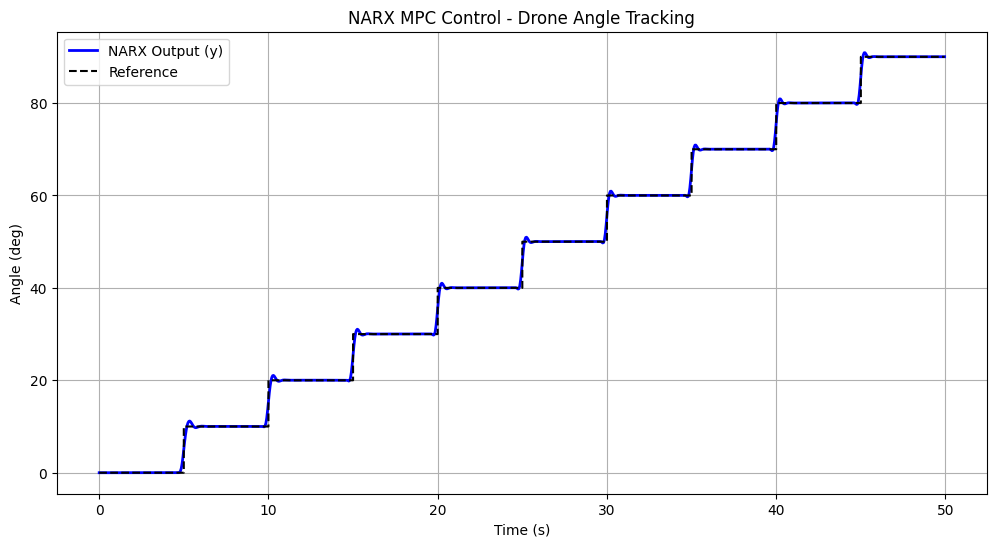

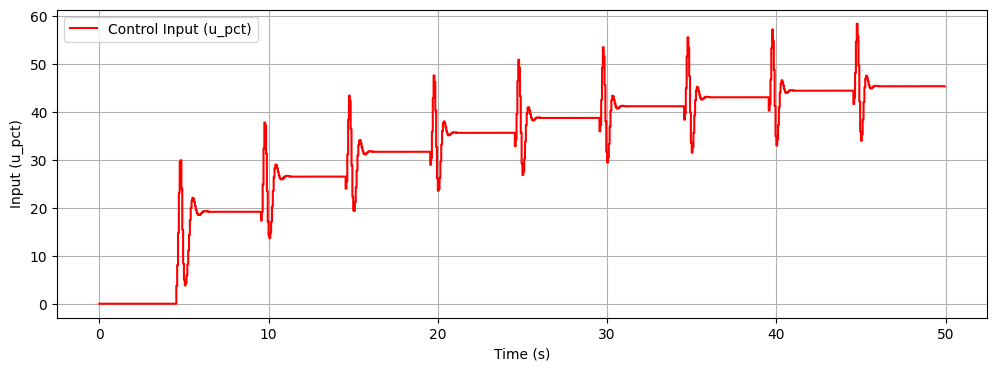

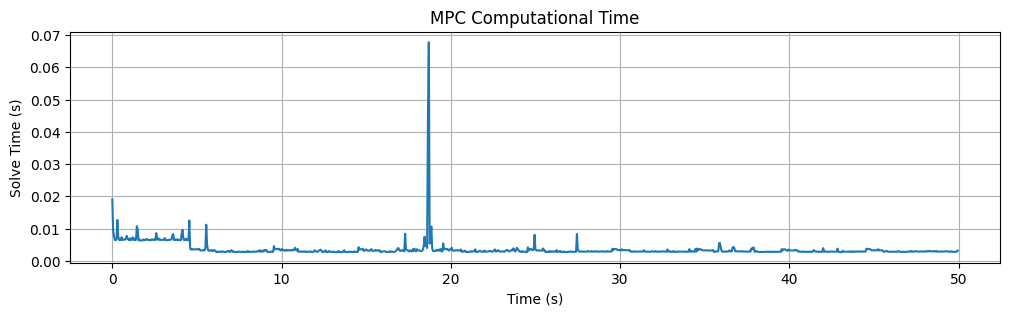

In [7]:
# 6. Plotting Results
plt.figure(figsize=(12, 6))
plt.plot(tvec_sim, ysim, 'b-', linewidth=2, label='NARX Output (y)')
plt.step(tvec_sim, x2ref[:len(tvec_sim)], where='post', color='k', linestyle='--', label='Reference')
plt.ylabel('Angle (deg)')
plt.xlabel('Time (s)')
plt.title('NARX MPC Control - Drone Angle Tracking')
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(12, 4))
plt.step(tvec_sim, usim, where='post', color='r', label='Control Input (u_pct)')
plt.ylabel('Input (u_pct)')
plt.xlabel('Time (s)')
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(12, 3))
plt.plot(tvec_sim, dtvec)
plt.grid(True)
plt.xlabel('Time (s)')
plt.ylabel('Solve Time (s)')
plt.title('MPC Computational Time')
plt.show()


## Dataset Generation
Using a rich combination of sine, step, and chirp signals.

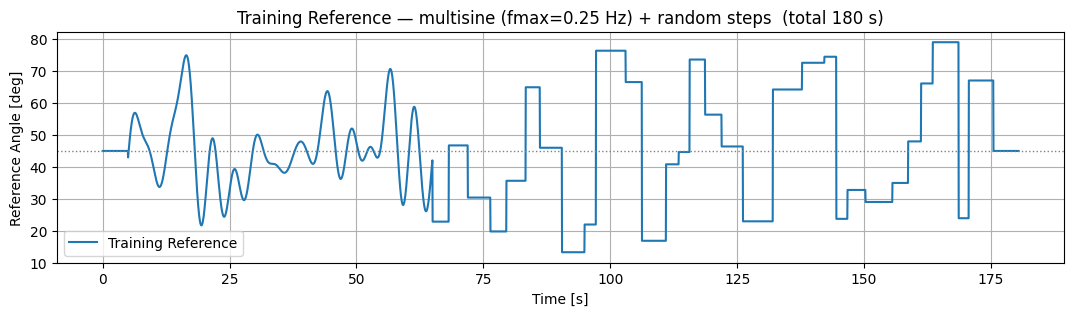

In [8]:
# 7. Training Reference Signal Generation (multisine + random steps)
np.random.seed(42)

SETPOINT = 45.0     # operating point [deg]
HOLD_45 = 5.0       # 45-deg holds at start and end [s]

# --- Multisine segment: fmax = 0.25 Hz, centered at 45 deg, +/- 30 deg ---
ms_duration = 60.0
f_max = 0.25
ms_amp = 30.0
n_ms = int(round(ms_duration / Ts))
t_ms_seg = np.arange(n_ms) * Ts
df = 1.0 / ms_duration                       # frequency resolution
freqs = np.arange(df, f_max + 1e-9, df)      # harmonics up to f_max
phases = np.random.uniform(0, 2 * np.pi, len(freqs))
ms = np.sum([np.sin(2*np.pi*f*t_ms_seg + ph) for f, ph in zip(freqs, phases)], axis=0)
ms = ms / np.max(np.abs(ms)) * ms_amp + SETPOINT

# --- Random-steps segment: amplitude [10, 80] deg, duration 2-6 s ---
n_steps = 30
amp_min, amp_max = 10.0, 80.0
dur_min, dur_max = 2.0, 6.0
step_pieces = []
for _ in range(n_steps):
    S = np.random.uniform(amp_min, amp_max)
    dur = np.random.uniform(dur_min, dur_max)
    step_pieces.append(np.full(int(round(dur / Ts)), S))
steps_seg = np.concatenate(step_pieces)

# --- Assemble: [45 hold] + multisine + random steps + [45 hold] ---
hold = np.full(int(round(HOLD_45 / Ts)), SETPOINT)
x2ref_train = np.concatenate([hold, ms, steps_seg, hold])

steps_train = len(x2ref_train)
tvec_train = np.arange(steps_train) * Ts

plt.figure(figsize=(13, 3))
plt.plot(tvec_train, x2ref_train, label='Training Reference')
plt.axhline(SETPOINT, color='gray', ls=':', lw=1)
plt.xlabel('Time [s]'); plt.ylabel('Reference Angle [deg]')
plt.title(f'Training Reference — multisine (fmax={f_max} Hz) + random steps  (total {steps_train*Ts:.0f} s)')
plt.legend(); plt.grid(True); plt.show()


Simulating MPC over Rich Signal for Dataset...


MPC Dataset Collection:   0%|          | 0/3600 [00:00<?, ?it/s]

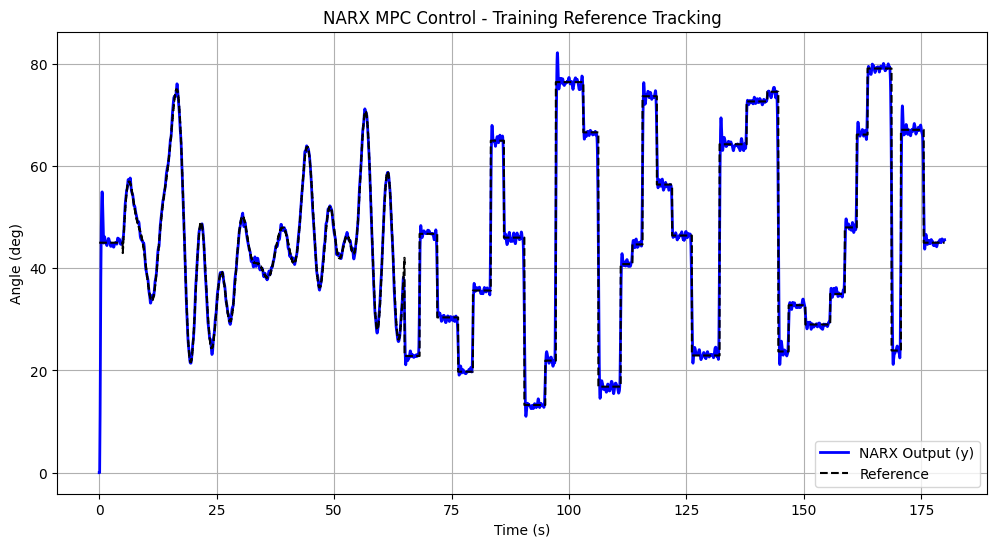

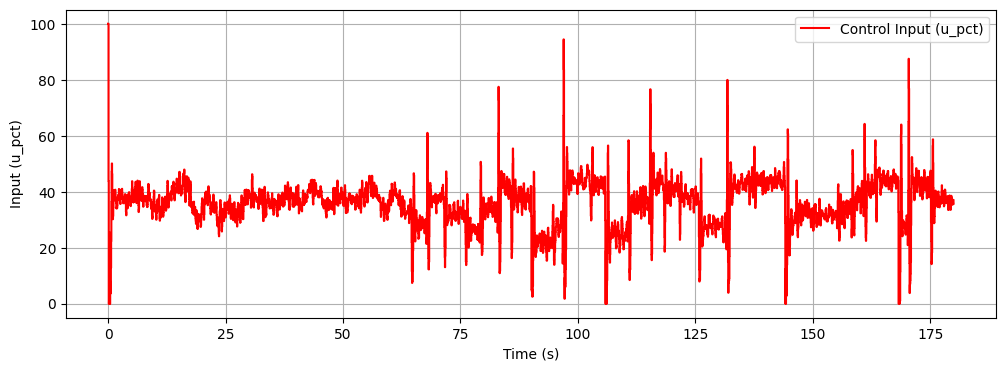

In [9]:
# 8. Simulation Loop (Rich Signal Dataset Collection)
xsim_train = np.zeros((nx, 1))
ysim_train = []
usim_train = []
w0_val = np.zeros(w.shape[0])

print("Simulating MPC over Rich Signal for Dataset...")
sim_steps_train = steps_train - N
for k in tqdm(range(sim_steps_train), desc="MPC Dataset Collection"):
    ref_window = x2ref_train[k : k + N]
    pval = np.concatenate([xsim_train[:, -1], ref_window])
    
    sol = solver(x0=w0_val, lbx=lbw, ubx=ubw, lbg=lbg, ubg=ubg, p=pval)
    
    w_opt = sol['x'].full().flatten()
    u_opt = w_opt[nx]
    
    # Add exploratory noise to the applied control input (NEW)
    u_applied = np.random.normal(u_opt, 3.0)  # NEW: standard deviation of 3.0% control noise
    u_applied = np.clip(u_applied, data['u_min'][0], data['u_max'][0])  # NEW: respect bounds
    
    sim_step = F(x0=xsim_train[:, -1], p=u_applied)  # NEW: apply noisy control to model
    xk1 = sim_step['xf'].full().flatten()
    yk = sim_step['yk'].full().item()
    
    xsim_train = np.c_[xsim_train, xk1]
    usim_train.append(u_opt)  # Target remains the optimal control (NEW)
    ysim_train.append(yk)
    w0_val = w_opt

# Collect Dataset for ANN
# P_data = np.array([np.concatenate([xsim_train[:, k], x2ref_train[k : k + N]]) for k in range(sim_steps_train)])
P_data = np.array([np.concatenate([xsim_train[:, k], x2ref_train[k : k + N]]) for k in range(sim_steps_train)])
U_data = np.array(usim_train).reshape(-1, 1)


# --- Plotting MPC Results ---
tvec_sim_train = tvec_train[:sim_steps_train]
# 1. Output (y) vs Reference
plt.figure(figsize=(12, 6))
plt.plot(tvec_sim_train, ysim_train, 'b-', linewidth=2, label='NARX Output (y)')
plt.step(tvec_sim_train, x2ref_train[:sim_steps_train], where='post', color='k', linestyle='--', label='Reference')
plt.ylabel('Angle (deg)')
plt.xlabel('Time (s)')
plt.title('NARX MPC Control - Training Reference Tracking')
plt.grid(True)
plt.legend()
plt.show()
# 2. Control Input (u)
plt.figure(figsize=(12, 4))
plt.step(tvec_sim_train, usim_train, where='post', color='r', label='Control Input (u_pct)')
plt.ylabel('Input (u_pct)')
plt.xlabel('Time (s)')
plt.grid(True)
plt.legend()
plt.show()


Training ANN...


Epoch 10/150 - Train Loss: 11.7161 - Val Loss: 11.5132
Epoch 20/150 - Train Loss: 6.8978 - Val Loss: 7.1934


Epoch 30/150 - Train Loss: 4.9796 - Val Loss: 7.2470
Epoch 40/150 - Train Loss: 3.5367 - Val Loss: 4.6769


Epoch 50/150 - Train Loss: 2.8358 - Val Loss: 6.1052
Epoch 60/150 - Train Loss: 2.1821 - Val Loss: 4.1445


Epoch 70/150 - Train Loss: 1.9605 - Val Loss: 3.8935
Epoch 80/150 - Train Loss: 1.6055 - Val Loss: 3.3342


Epoch 90/150 - Train Loss: 1.5367 - Val Loss: 3.5013
Epoch 100/150 - Train Loss: 1.3198 - Val Loss: 3.0790


Epoch 110/150 - Train Loss: 1.2389 - Val Loss: 2.7823


Epoch 120/150 - Train Loss: 1.1113 - Val Loss: 2.6238
Epoch 130/150 - Train Loss: 0.9508 - Val Loss: 2.6369


Epoch 140/150 - Train Loss: 0.8939 - Val Loss: 2.3350
Epoch 150/150 - Train Loss: 0.8681 - Val Loss: 2.9264


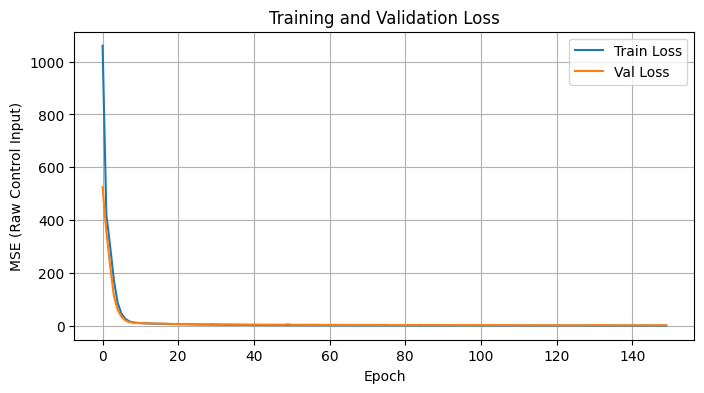

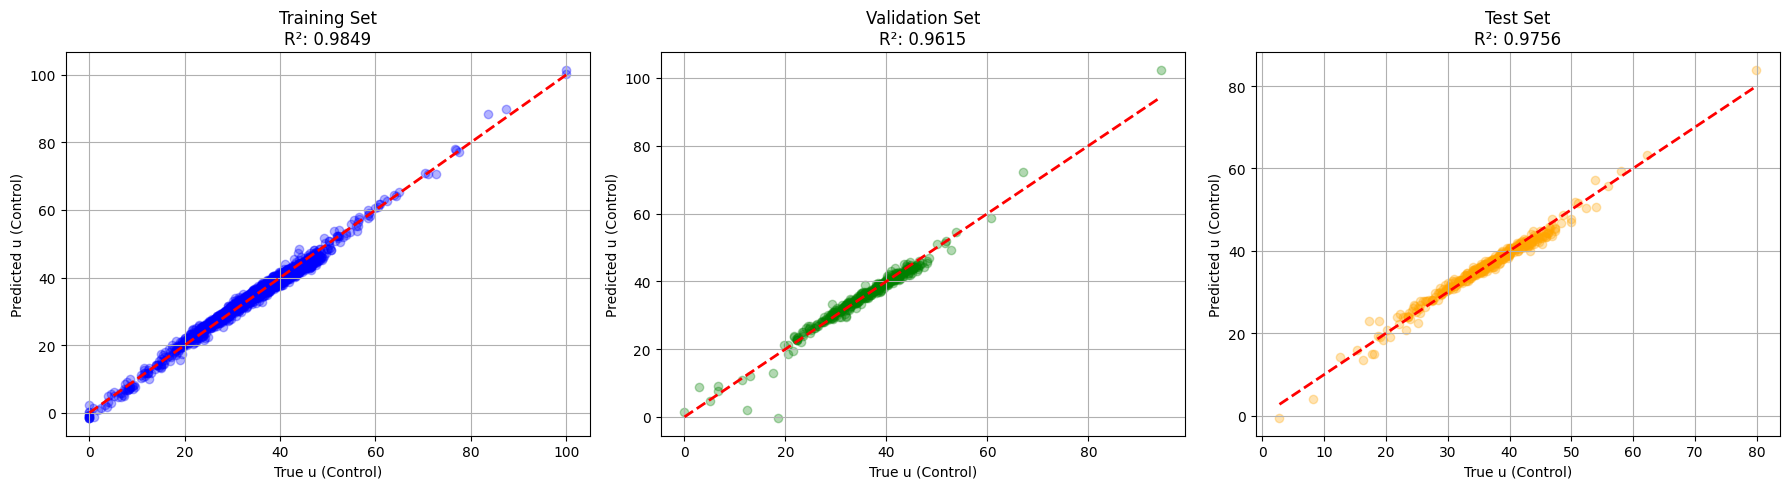

In [10]:
# 9. ANN Creation and Training
# Define the MLP (increased capacity for nx+N=35 inputs)
class MPCApproximator(nn.Module):
    def __init__(self, input_dim, output_dim):
        super(MPCApproximator, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128),
            nn.ReLU(),
            nn.Linear(128, 128),
            nn.ReLU(),
            nn.Linear(128, output_dim)
        )
        
    def forward(self, x):
        return self.net(x)

# Normalize inputs ONLY using StandardScaler to match robust template
scaler = StandardScaler()
P_scaled = scaler.fit_transform(P_data)

# Split data into train, validation, and test sets to monitor overfitting and evaluate generalization
X_train_val, X_test, y_train_val, y_test = train_test_split(P_scaled, U_data, test_size=0.1, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_train_val, y_train_val, test_size=0.1111, random_state=42)

tensor_X_train = torch.tensor(X_train, dtype=torch.float32)
tensor_y_train = torch.tensor(y_train, dtype=torch.float32)
tensor_X_val = torch.tensor(X_val, dtype=torch.float32)
tensor_y_val = torch.tensor(y_val, dtype=torch.float32)
tensor_X_test = torch.tensor(X_test, dtype=torch.float32)
tensor_y_test = torch.tensor(y_test, dtype=torch.float32)

train_dataset = TensorDataset(tensor_X_train, tensor_y_train)
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)

# model = MPCApproximator(input_dim=nx + N, output_dim=1)
model = MPCApproximator(input_dim=nx + N, output_dim=1)
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)  # NEW: reduced for training stability

epochs = 150  # NEW: increased epochs to allow model to converge fully
train_loss_history = []
val_loss_history = []

print("Training ANN...")
for epoch in range(epochs):
    model.train()
    epoch_loss = 0.0
    for batch_X, batch_y in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_X)
        loss = criterion(outputs, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item()
    train_loss_history.append(epoch_loss / len(train_loader))
    
    # Validation
    model.eval()
    with torch.no_grad():
        val_outputs = model(tensor_X_val)
        val_loss = criterion(val_outputs, tensor_y_val).item()
    val_loss_history.append(val_loss)
    
    if (epoch+1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss_history[-1]:.4f} - Val Loss: {val_loss_history[-1]:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(train_loss_history, label='Train Loss')
plt.plot(val_loss_history, label='Val Loss')
plt.title("Training and Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("MSE (Raw Control Input)")
plt.legend()
plt.grid()
plt.show()

# Plot y vs yhat on training, val, and test (side by side)
model.eval()
with torch.no_grad():
    y_train_pred = model(tensor_X_train).numpy()
    y_val_pred = model(tensor_X_val).numpy()
    y_test_pred = model(tensor_X_test).numpy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Training plot
axes[0].scatter(y_train, y_train_pred, alpha=0.3, color='blue')
axes[0].plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--', lw=2)
axes[0].set_title(f"Training Set\nR²: {r2_score(y_train, y_train_pred):.4f}")
axes[0].set_xlabel("True u (Control)")
axes[0].set_ylabel("Predicted u (Control)")
axes[0].grid(True)

# Validation plot
axes[1].scatter(y_val, y_val_pred, alpha=0.3, color='green')
axes[1].plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--', lw=2)
axes[1].set_title(f"Validation Set\nR²: {r2_score(y_val, y_val_pred):.4f}")
axes[1].set_xlabel("True u (Control)")
axes[1].set_ylabel("Predicted u (Control)")
axes[1].grid(True)

# Test plot
axes[2].scatter(y_test, y_test_pred, alpha=0.3, color='orange')
axes[2].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
axes[2].set_title(f"Test Set\nR²: {r2_score(y_test, y_test_pred):.4f}")
axes[2].set_xlabel("True u (Control)")
axes[2].set_ylabel("Predicted u (Control)")
axes[2].grid(True)

plt.tight_layout()
plt.show()


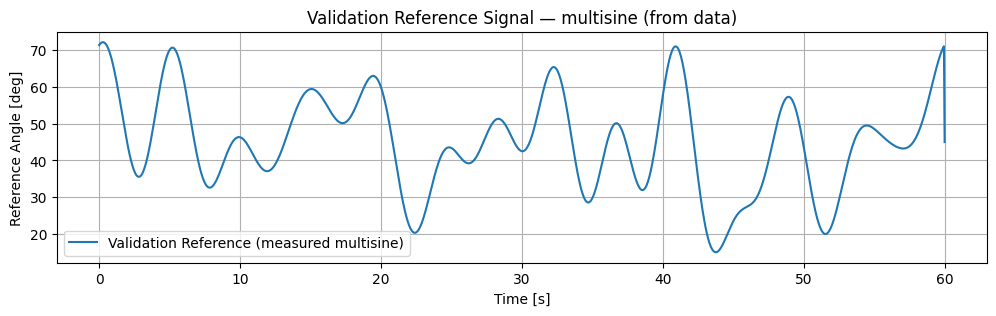

In [11]:
# 10. Validation Test Signal Generation (measured multisine reference)
u_vref, y_vref, t_vref, ref_vref = load_processed('multiseno')
x2ref_val = ref_vref.copy()
steps_test = len(x2ref_val)
tvec_test = np.arange(steps_test) * Ts

plt.figure(figsize=(12, 3))
plt.plot(tvec_test, x2ref_val, label='Validation Reference (measured multisine)')
plt.xlabel('Time [s]'); plt.ylabel('Reference Angle [deg]')
plt.title('Validation Reference Signal — multisine (from data)')
plt.legend(); plt.grid(True); plt.show()


MPC: total 3.60 s | mean 3.03 ms/step
ANN: total 0.07 s | mean 0.055 ms/step
Speedup Factor (mean per step): 55.1x


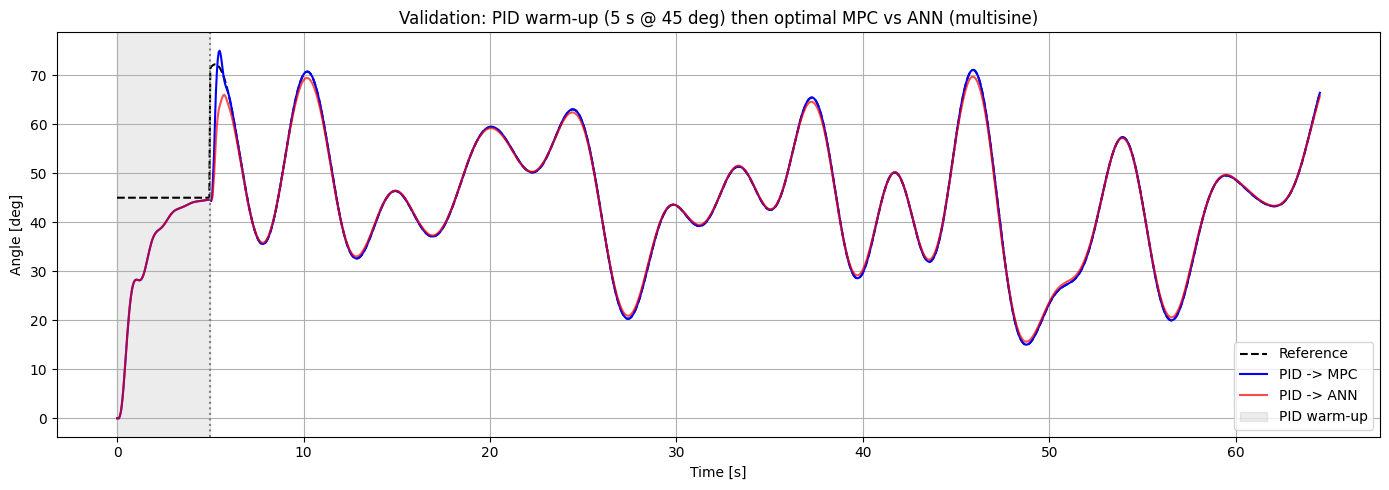

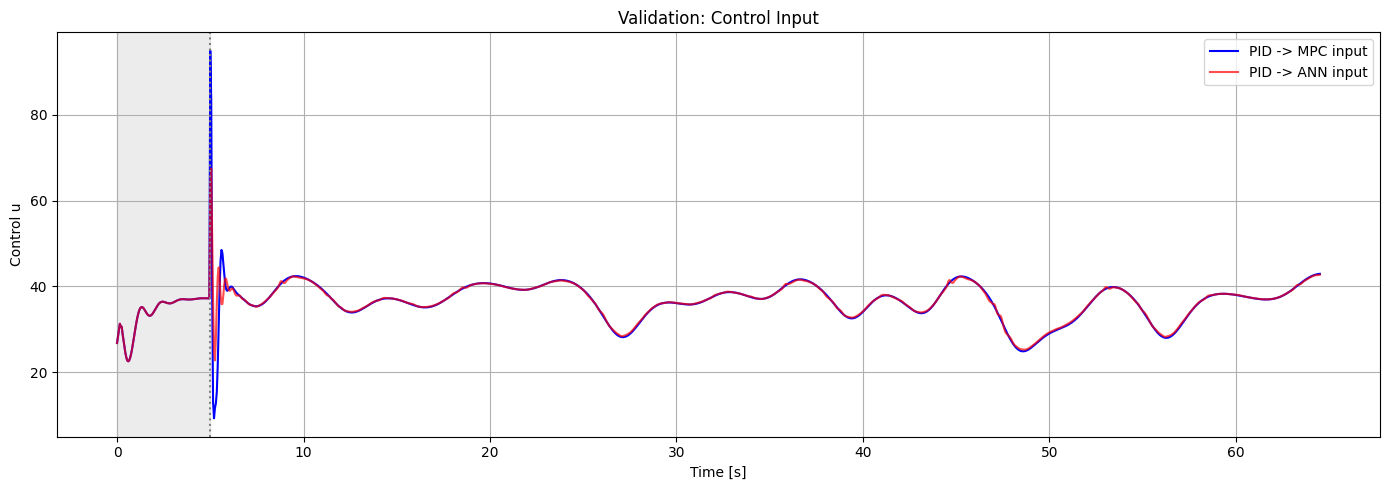

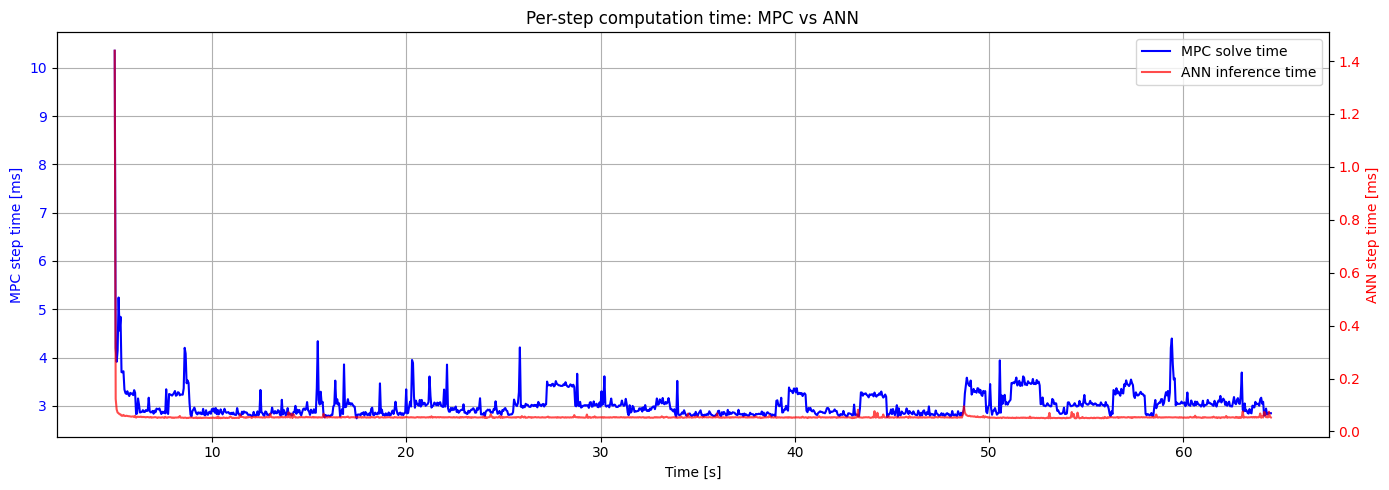

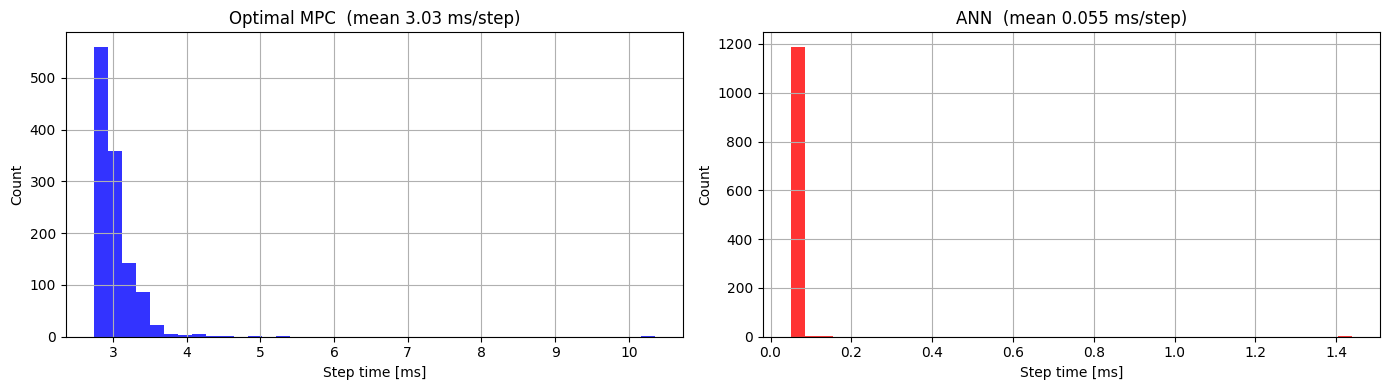

In [12]:
# 11. Validation: PID warm-up (CI=0, 45 deg, 5 s) then optimal MPC vs ANN (multisine)

# --- Phase 1: HIL PID controller (gains/structure from hil_pid.py) ---
Kp, Ki, Kd = 0.5793, 0.6647, 0.2
ref_pid = 45.0
t_pid = 5.0
n_pid = int(round(t_pid / Ts))

xs = np.zeros((nx, 1))           # initial condition = 0
y_pid, u_pid = [], []
e_1 = 0.0; u_i = 0.0; y_1 = 0.0; y_atual = 0.0
for step in range(n_pid):
    erro = ref_pid - y_atual
    u_p = Kp * erro
    u_i = u_i + Ki * (Ts / 2.0) * (erro + e_1)        # trapezoidal integral
    u_d = -(Kd / Ts) * (y_atual - y_1)                # derivative on measurement
    u_calc = u_p + u_i + u_d
    u_opt = float(np.clip(u_calc, -10.0, 80.0))
    if u_calc != u_opt:                               # anti-windup (back-calculation)
        u_i -= (u_calc - u_opt)
    e_1 = erro; y_1 = y_atual
    res = F(x0=xs[:, -1], p=u_opt)
    xs = np.c_[xs, res['xf'].full().flatten()]
    y_atual = float(res['yk'])
    y_pid.append(y_atual); u_pid.append(u_opt)

x_after_pid = xs[:, -1]          # state handed over to MPC / ANN

# --- Phase 2: optimal MPC vs ANN on the multisine reference ---
sim_steps_test = steps_test - N

# MPC (timing the solve at each step)
xsim_mpc = x_after_pid.reshape(-1, 1)
y_mpc, u_mpc, dt_mpc = [], [], []
w0_val = np.zeros(w.shape[0])
for k in range(sim_steps_test):
    ref_window = x2ref_val[k:k + N]
    pval = np.concatenate([xsim_mpc[:, -1], ref_window])
    tic = time.perf_counter()
    sol = solver(x0=w0_val, lbx=lbw, ubx=ubw, lbg=lbg, ubg=ubg, p=pval)
    w_opt = sol['x'].full().flatten()
    u_o = w_opt[nx]
    dt_mpc.append(time.perf_counter() - tic)
    res = F(x0=xsim_mpc[:, -1], p=u_o)
    xsim_mpc = np.c_[xsim_mpc, res['xf'].full().flatten()]
    y_mpc.append(float(res['yk'])); u_mpc.append(u_o)
    w0_val = w_opt

# ANN (timing the inference at each step)
xsim_ann = x_after_pid.reshape(-1, 1)
y_ann, u_ann, dt_ann = [], [], []
model.eval()
with torch.no_grad():
    for k in range(sim_steps_test):
        ref_window = x2ref_val[k:k + N]
        pval = np.concatenate([xsim_ann[:, -1], ref_window])
        tic = time.perf_counter()
        pval_scaled = scaler.transform(pval.reshape(1, -1))
        u_o = float(np.clip(model(torch.tensor(pval_scaled, dtype=torch.float32)).item(),
                            data['u_min'][0], data['u_max'][0]))
        dt_ann.append(time.perf_counter() - tic)
        res = F(x0=xsim_ann[:, -1], p=u_o)
        xsim_ann = np.c_[xsim_ann, res['xf'].full().flatten()]
        y_ann.append(float(res['yk'])); u_ann.append(u_o)

dt_mpc = np.array(dt_mpc); dt_ann = np.array(dt_ann)
print(f'MPC: total {dt_mpc.sum():.2f} s | mean {dt_mpc.mean()*1e3:.2f} ms/step')
print(f'ANN: total {dt_ann.sum():.2f} s | mean {dt_ann.mean()*1e3:.3f} ms/step')
print(f'Speedup Factor (mean per step): {dt_mpc.mean()/dt_ann.mean():.1f}x')

# --- Combined plots: PID warm-up + (MPC | ANN) ---
t_p1 = np.arange(n_pid) * Ts
t_p2 = t_pid + np.arange(sim_steps_test) * Ts
t_full = np.concatenate([t_p1, t_p2])
ref_full = np.concatenate([np.full(n_pid, ref_pid), x2ref_val[:sim_steps_test]])

plt.figure(figsize=(14, 5))
plt.plot(t_full, ref_full, 'k--', label='Reference')
plt.plot(t_full, np.concatenate([y_pid, y_mpc]), 'b-', label='PID -> MPC')
plt.plot(t_full, np.concatenate([y_pid, y_ann]), 'r-', alpha=0.7, label='PID -> ANN')
plt.axvspan(0, t_pid, color='gray', alpha=0.15, label='PID warm-up')
plt.axvline(t_pid, color='gray', ls=':')
plt.xlabel('Time [s]'); plt.ylabel('Angle [deg]')
plt.title('Validation: PID warm-up (5 s @ 45 deg) then optimal MPC vs ANN (multisine)')
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

plt.figure(figsize=(14, 5))
plt.plot(t_full, np.concatenate([u_pid, u_mpc]), 'b-', label='PID -> MPC input')
plt.plot(t_full, np.concatenate([u_pid, u_ann]), 'r-', alpha=0.7, label='PID -> ANN input')
plt.axvspan(0, t_pid, color='gray', alpha=0.15)
plt.axvline(t_pid, color='gray', ls=':')
plt.xlabel('Time [s]'); plt.ylabel('Control u'); plt.title('Validation: Control Input')
plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

# --- Per-step computation time: MPC vs ANN (twin y-axes) ---
fig, ax1 = plt.subplots(figsize=(14, 5))
ax1.plot(t_p2, dt_mpc * 1e3, 'b-', label='MPC solve time')
ax1.set_xlabel('Time [s]'); ax1.set_ylabel('MPC step time [ms]', color='b')
ax1.tick_params(axis='y', labelcolor='b'); ax1.grid(True)
ax2 = ax1.twinx()
ax2.plot(t_p2, dt_ann * 1e3, 'r-', alpha=0.7, label='ANN inference time')
ax2.set_ylabel('ANN step time [ms]', color='r'); ax2.tick_params(axis='y', labelcolor='r')
ax1.set_title('Per-step computation time: MPC vs ANN')
l1, lab1 = ax1.get_legend_handles_labels(); l2, lab2 = ax2.get_legend_handles_labels()
ax1.legend(l1 + l2, lab1 + lab2, loc='upper right')
plt.tight_layout(); plt.show()

# --- Histograms of per-step computation time (side by side) ---
fig, (axA, axB) = plt.subplots(1, 2, figsize=(14, 4))
axA.hist(dt_mpc * 1e3, bins=40, color='b', alpha=0.8)
axA.set_title(f'Optimal MPC  (mean {dt_mpc.mean()*1e3:.2f} ms/step)')
axA.set_xlabel('Step time [ms]'); axA.set_ylabel('Count'); axA.grid(True)
axB.hist(dt_ann * 1e3, bins=40, color='r', alpha=0.8)
axB.set_title(f'ANN  (mean {dt_ann.mean()*1e3:.3f} ms/step)')
axB.set_xlabel('Step time [ms]'); axB.set_ylabel('Count'); axB.grid(True)
plt.tight_layout(); plt.show()
